ejercicio 4


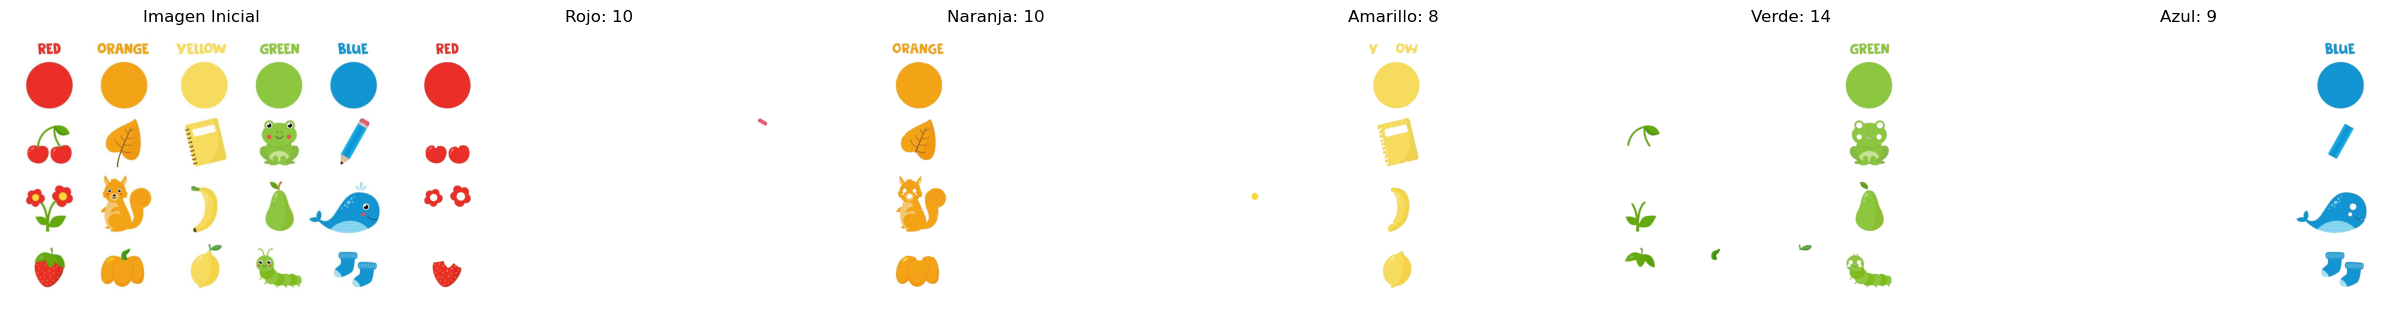

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segmentar_fondo_blanco(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Rangos ajustados para los colores de tu imagen específica
    # Se ha ampliado el rango de saturación y valor para captar mejor los tonos
    colores = {
        'Rojo': [([0, 100, 100], [10, 255, 255]), ([170, 100, 100], [180, 255, 255])],
        'Naranja': [([11, 100, 100], [22, 255, 255])],
        'Amarillo': [([23, 80, 100], [35, 255, 255])],
        'Verde': [([36, 50, 100], [85, 255, 255])],
        'Azul': [([86, 50, 100], [130, 255, 255])]
    }

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Imagen Inicial')
    axes[0].axis('off')

    for i, (nombre, rangos) in enumerate(colores.items()):
        # Crear máscara
        mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
        for bajo, alto in rangos:
            mask += cv2.inRange(hsv, np.array(bajo), np.array(alto))
        
        # Limpieza de ruido
        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        
        # Contar objetos (ignorando ruido pequeño)
        contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        objetos = [c for c in contornos if cv2.contourArea(c) > 400]
        
        # --- Crear fondo blanco ---
        # Creamos una imagen blanca del mismo tamaño
        resultado = np.ones_like(img_rgb) * 255
        # Copiamos solo los píxeles de la fruta a la imagen blanca
        for c in objetos:
            x, y, w, h = cv2.boundingRect(c)
            roi = img_rgb[y:y+h, x:x+w]
            roi_mask = mask[y:y+h, x:x+w]
            # Usamos la máscara para pegar el objeto sobre el fondo blanco
            idx = roi_mask > 0
            resultado[y:y+h, x:x+w][idx] = roi[idx]

        axes[i+1].imshow(resultado)
        axes[i+1].set_title(f'{nombre}: {len(objetos)}')
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Ruta
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\frutas.jpg'
segmentar_fondo_blanco(ruta)